## 1. Import Library

In [1]:
import kagglehub
import glob
import os
import random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
from collections import Counter
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.applications import EfficientNetV2B0
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
import keras as kr

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [2]:
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [3]:
print("Keras version:", kr.__version__)

Keras version: 3.13.2


## 2. Import Dataset

In [4]:
dataset_path = kagglehub.dataset_download("gradientvoyager/faceforensics-c23-extracted-faces-100k")
print("Dataset downloaded to:", dataset_path)

root = os.path.join(dataset_path, "dataset_processed_split")
print("Root path:", root)
print("Contents:", os.listdir(root))

100%|██████████| 2.46G/2.46G [00:21<00:00, 124MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/gradientvoyager/faceforensics-c23-extracted-faces-100k/versions/1
Root path: /root/.cache/kagglehub/datasets/gradientvoyager/faceforensics-c23-extracted-faces-100k/versions/1/dataset_processed_split
Contents: ['dataset_manifest.csv', 'train', 'test', 'val']


## 3. Data Preparation

In [5]:
FAKE_CLASSES = {
    "deepfakes",
    "face2face",
    "faceshifter",
    "faceswap",
    "neuraltextures"
}
VALID_EXT = (".jpg", ".jpeg")

def load_image_paths_with_subclass(folder):
    image_paths = glob.glob(os.path.join(folder, "**", "*.*"), recursive=True)
    data = []
    for path in image_paths:
        if not path.lower().endswith(VALID_EXT):
            continue
        class_name = os.path.basename(os.path.dirname(path)).lower()
        if class_name == "real":
            label = 0
        elif class_name in FAKE_CLASSES:
            label = 1
        else:
            continue
        data.append((path, label, class_name))
    return data

In [6]:
train_dir = os.path.join(root, "train")
test_dir  = os.path.join(root, "test")
val_dir   = os.path.join(root, "val")

train_data = load_image_paths_with_subclass(train_dir)
test_data  = load_image_paths_with_subclass(test_dir)
val_data   = load_image_paths_with_subclass(val_dir)

print(f"Train : {len(train_data):,} images")
print(f"Val   : {len(val_data):,} images")
print(f"Test  : {len(test_data):,} images")
print()

# Class distribution
for split_name, split in [("Train", train_data), ("Val", val_data), ("Test", test_data)]:
    counts = Counter(label for _, label, _ in split)
    total = len(split)
    print(f"{split_name}: Real={counts[0]:,} ({counts[0]/total*100:.1f}%), "
          f"Fake={counts[1]:,} ({counts[1]/total*100:.1f}%)")

Train : 108,597 images
Val   : 24,208 images
Test  : 23,276 images

Train: Real=18,391 (16.9%), Fake=90,206 (83.1%)
Val: Real=4,109 (17.0%), Fake=20,099 (83.0%)
Test: Real=3,944 (16.9%), Fake=19,332 (83.1%)


In [7]:
def subsample_stratified(data, max_per_class, seed=42):
    random.seed(seed)

    real = [(p, l, c) for p, l, c in data if l == 0]

    fake_by_class = {}
    for p, l, c in data:
        if l == 1:
            fake_by_class.setdefault(c, []).append((p, l, c))

    n_fake_classes  = len(fake_by_class)
    per_subclass    = max_per_class // n_fake_classes

    sampled_fake = []
    for cls, items in fake_by_class.items():
        sampled_fake += random.sample(items, min(len(items), per_subclass))

    sampled_real = random.sample(real, min(len(real), max_per_class))
    sampled      = sampled_real + sampled_fake
    random.shuffle(sampled)

    return sampled

def subsample_imbalanced(data, n_real, n_fake, seed=42):
    random.seed(seed)

    real = [(p, l, c) for p, l, c in data if l == 0]

    fake_by_class = {}
    for p, l, c in data:
        if l == 1:
            fake_by_class.setdefault(c, []).append((p, l, c))

    n_fake_classes = len(fake_by_class)
    per_subclass   = n_fake // n_fake_classes


    sampled_fake = []
    for cls, items in fake_by_class.items():
        sampled = random.sample(items, min(len(items), per_subclass))
        sampled_fake += sampled

    sampled_real = random.sample(real, min(len(real), n_real))

    sampled_result = sampled_real + sampled_fake
    random.shuffle(sampled_result)
    return sampled_result

train_data = subsample_stratified(train_data, max_per_class=18000)
val_data = subsample_stratified(val_data,   max_per_class=1000)
test_data = subsample_imbalanced(test_data, n_real=950, n_fake=1050)

counts_t  = Counter(l for _, l, _ in train_data)
counts_v  = Counter(l for _, l, _ in val_data)
counts_te = Counter(l for _, l, _ in test_data)

print(f"Train  — Real: {counts_t[0]:,} | Fake: {counts_t[1]:,}")
print(f"Val    — Real: {counts_v[0]:,} | Fake: {counts_v[1]:,}")
print(f"Test   — Real: {counts_te[0]:,} | Fake: {counts_te[1]:,} images (imbalanced, agar realistis dengan data dunia nyata)")
print()

for name, split in [("Train (balanced)", train_data), ("Val (balanced)", val_data), ("Test (imbalanced)", test_data)]:
    counts = Counter(l for _, l, _ in split)
    total  = len(split)
    print(f"{name}: {total:,} total | Real={counts[0]:,} ({counts[0]/total*100:.1f}%) | Fake={counts[1]:,} ({counts[1]/total*100:.1f}%)")

Train  — Real: 18,000 | Fake: 18,000
Val    — Real: 1,000 | Fake: 1,000
Test   — Real: 950 | Fake: 1,050 images (imbalanced, agar realistis dengan data dunia nyata)

Train (balanced): 36,000 total | Real=18,000 (50.0%) | Fake=18,000 (50.0%)
Val (balanced): 2,000 total | Real=1,000 (50.0%) | Fake=1,000 (50.0%)
Test (imbalanced): 2,000 total | Real=950 (47.5%) | Fake=1,050 (52.5%)


In [8]:
def check_subclass_distribution(data, split_name):
    subclass_counts = Counter(class_name for _, _, class_name in data)
    total = len(data)

    print(f"\n{'='*50}")
    print(f"  {split_name} — Subclass Distribution")
    print(f"{'='*50}")


    all_classes = ["real"] + sorted(FAKE_CLASSES)

    for cls in all_classes:
        count = subclass_counts.get(cls, 0)
        pct   = count / total * 100 if total > 0 else 0
        print(f"  {cls:<20} : {count:>6,} ({pct:5.1f}%)")

    print(f"  {'TOTAL':<20} : {total:>6,} (100.0%)")

    fake_counts = {k: v for k, v in subclass_counts.items() if k != "real"}
    if fake_counts:
        max_count = max(fake_counts.values())
        min_count = min(fake_counts.values())
        ratio     = max_count / min_count if min_count > 0 else float("inf")
        balanced  = "SEIMBANG" if ratio < 1.5 else "TIDAK SEIMBANG"
        print(f"\n  Rasio fake subclass: {ratio:.2f}  =  {balanced}")

# Jalankan untuk semua split
for name, split in [("Train", train_data), ("Val", val_data), ("Test", test_data)]:
    check_subclass_distribution(split, name)


  Train — Subclass Distribution
  real                 : 18,000 ( 50.0%)
  deepfakes            :  3,600 ( 10.0%)
  face2face            :  3,600 ( 10.0%)
  faceshifter          :  3,600 ( 10.0%)
  faceswap             :  3,600 ( 10.0%)
  neuraltextures       :  3,600 ( 10.0%)
  TOTAL                : 36,000 (100.0%)

  Rasio fake subclass: 1.00  =  SEIMBANG

  Val — Subclass Distribution
  real                 :  1,000 ( 50.0%)
  deepfakes            :    200 ( 10.0%)
  face2face            :    200 ( 10.0%)
  faceshifter          :    200 ( 10.0%)
  faceswap             :    200 ( 10.0%)
  neuraltextures       :    200 ( 10.0%)
  TOTAL                :  2,000 (100.0%)

  Rasio fake subclass: 1.00  =  SEIMBANG

  Test — Subclass Distribution
  real                 :    950 ( 47.5%)
  deepfakes            :    210 ( 10.5%)
  face2face            :    210 ( 10.5%)
  faceshifter          :    210 ( 10.5%)
  faceswap             :    210 ( 10.5%)
  neuraltextures       :    210 ( 10.5%)


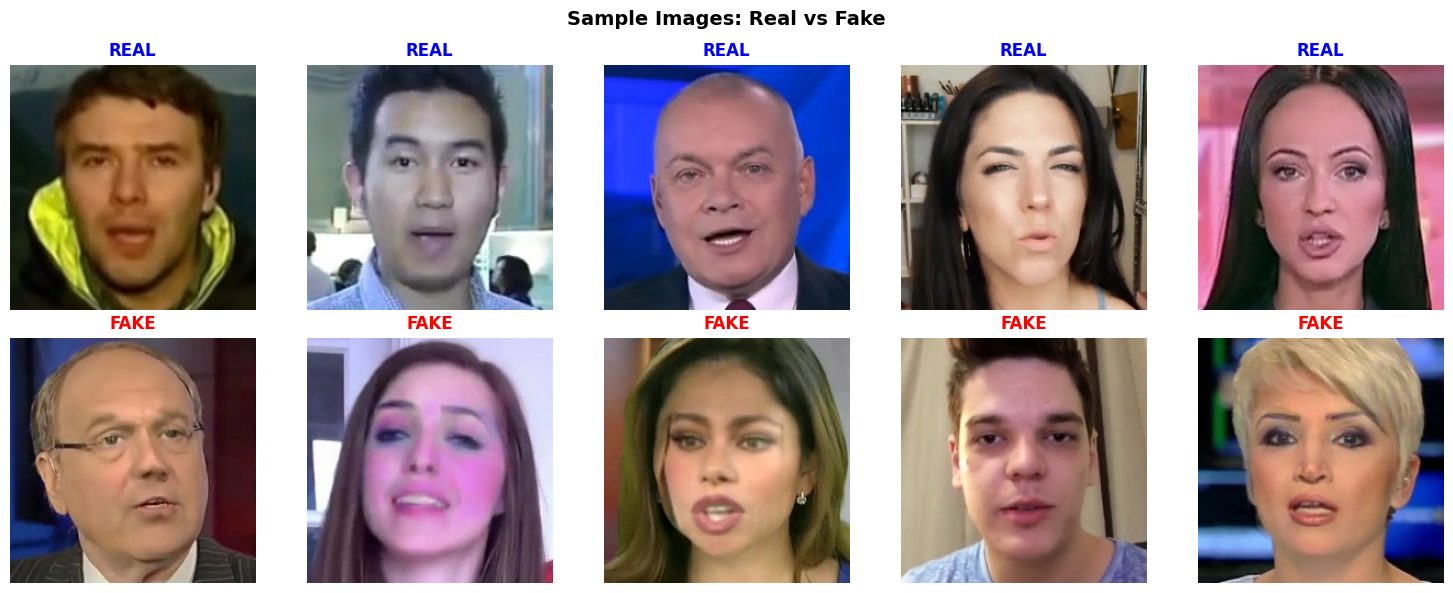

In [9]:
# Visualize sample images
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
real_samples = [(p, l) for p, l, _ in train_data if l == 0][:5]
fake_samples = [(p, l) for p, l, _ in train_data if l == 1][:5]

for i, (path, label) in enumerate(real_samples):
    axes[0, i].imshow(Image.open(path))
    axes[0, i].set_title("REAL", color="blue", fontweight="bold")
    axes[0, i].axis("off")

for i, (path, label) in enumerate(fake_samples):
    axes[1, i].imshow(Image.open(path))
    axes[1, i].set_title("FAKE", color="red", fontweight="bold")
    axes[1, i].axis("off")

plt.suptitle("Sample Images: Real vs Fake", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [10]:
IMG_SIZE    = (224, 224)
INPUT_SHAPE = (*IMG_SIZE, 3)
BATCH_SIZE  = 64
AUTOTUNE    = tf.data.AUTOTUNE

def parse_image(path, label):
    img   = tf.io.read_file(path)
    img   = tf.image.decode_jpeg(img, channels=3)
    img   = tf.image.resize(img, IMG_SIZE)
    img   = tf.cast(img, tf.float32)
    label = tf.cast(label, tf.float32)
    return img, label

def jpeg_compression(x):
    x = tf.clip_by_value(x, 0.0, 255.0)
    x = tf.cast(x, tf.uint8)
    x = tf.image.random_jpeg_quality(x, 95, 100)
    x = tf.cast(x, tf.float32)
    return x

def add_gaussian_noise(x):
    stddev = tf.random.uniform([], 2.0, 5.0)
    noise = tf.random.normal(tf.shape(x), 0.0, stddev)
    return tf.clip_by_value(x + noise, 0.0, 255.0)

def custom_gaussian_blur(x):
    x = tf.expand_dims(x, 0)
    x = tf.nn.avg_pool2d(x, ksize=3, strides=1, padding="SAME")
    return tf.squeeze(x, 0)

def random_compress_or_noise_or_blur(x):
    x = tf.cond(
        tf.random.uniform([]) < 0.3,
        lambda: custom_gaussian_blur(x),
        lambda: x,
    )
    x = tf.cond(
        tf.random.uniform([]) < 0.6,
        lambda: jpeg_compression(x),
        lambda: x,
    )
    x = tf.cond(
        tf.random.uniform([]) < 0.2,
        lambda: add_gaussian_noise(x),
        lambda: x,
    )
    return x

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.03),
    layers.RandomZoom(0.03),
    layers.RandomBrightness(factor=0.18, value_range=(0.0, 255.0)),
    layers.RandomContrast(factor=0.18, value_range=(0.0, 255.0)),
    layers.Lambda(random_compress_or_noise_or_blur),
    layers.Lambda(lambda x: tf.clip_by_value(x, 0.0, 255.0)),
], name="data_augmentation")

def make_dataset(data, training=False, shuffle=False):
    paths  = [p for p, _, _ in data]
    labels = [l for _, l, _ in data]

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if shuffle:
        ds = ds.shuffle(buffer_size=min(len(data), 10_000), seed=SEED,
                        reshuffle_each_iteration=True)

    ds = ds.map(parse_image, num_parallel_calls=AUTOTUNE)

    if training:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y),
                    num_parallel_calls=AUTOTUNE)

    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

    return ds

train_ds = make_dataset(train_data, training=True,  shuffle=True)
val_ds   = make_dataset(val_data,   training=False, shuffle=False)
test_ds  = make_dataset(test_data,  training=False, shuffle=False)

print(f"Train batches : {len(train_ds)}")
print(f"Val batches   : {len(val_ds)}")
print(f"Test batches  : {len(test_ds)}")

Train batches : 563
Val batches   : 32
Test batches  : 32


In [11]:
for imgs, labels in train_ds.take(1):
    print("Min:", imgs.numpy().min().round(3))
    print("Max:", imgs.numpy().max().round(3))
    print("Mean:", imgs.numpy().mean().round(3))

Min: 0.0
Max: 255.0
Mean: 90.62


In [12]:
test_path, test_label, _ = train_data[0]

img_raw, lbl = parse_image(test_path, test_label)
print("After parse_image - Min:", img_raw.numpy().min().round(3),
      "Max:", img_raw.numpy().max().round(3))
print("Expected: Min ~0, Max ~255")


After parse_image - Min: 0.0 Max: 255.0
Expected: Min ~0, Max ~255


In [13]:
from collections import Counter
for name, data in [("Train", train_data), ("Val", val_data), ("Test", test_data)]:
    c = Counter([y for _, y, _ in data])
    print(f"{name:<6}: Counter({{0: {c[0]}, 1: {c[1]}}})")

Train : Counter({0: 18000, 1: 18000})
Val   : Counter({0: 1000, 1: 1000})
Test  : Counter({0: 950, 1: 1050})


## 4. Modelling (EfficientNetV2B0 — Transfer Learning)

In [14]:
def build_model(input_shape=INPUT_SHAPE):
    base_model = EfficientNetV2B0(
        include_top=False,
        weights="imagenet",
        input_shape=input_shape
    )
    base_model.trainable = False

    inputs = tf.keras.Input(shape=input_shape)
    x = base_model(inputs)
    avg = layers.GlobalAveragePooling2D()(x)
    mx  = layers.GlobalMaxPooling2D()(x)
    x   = layers.Concatenate()([avg, mx])
    x = layers.BatchNormalization()(x)
    x = layers.Dense(
        256,
        activation="relu",
        kernel_regularizer=regularizers.l2(1e-4),
        kernel_initializer="he_normal",
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(1, activation="sigmoid", dtype="float32")(x)

    model = tf.keras.Model(inputs, outputs, name="DeepfakeDetector_EfficientNetV2B0")
    return model, base_model

model, base_model = build_model()
model.summary()


24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "DeepfakeDetector_EfficientNetV2B0"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetv2-b0   │ (None, 7, 7,      │  5,919,312 │ input_layer_2[0]… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ efficientnetv2-b… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 1280)      │          0 │ efficientnetv2-b… │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 2560)      │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 2560)      │     10,240 │ concatenate[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    655,616 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │        257 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,586,449 (25.13 MB)

 Trainable params: 661,505 (2.52 MB)

 Non-trainable params: 5,924,944 (22.60 MB)

## 5. Training — Fase 1: Ekstraksi fitur train layer barunya ke dataset deepfake dulu

In [15]:
model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=7e-4, weight_decay=1e-4, clipnorm=1.0),
    loss=tf.keras.losses.BinaryFocalCrossentropy(
        gamma=2.0,
        label_smoothing=0.05
    ),
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc", dtype=tf.float32),
        tf.keras.metrics.Precision(name="precision", dtype=tf.float32),
        tf.keras.metrics.Recall(name="recall", dtype=tf.float32)
    ]
)

callbacks_phase1 = [
    EarlyStopping(
        monitor="val_auc",
        patience=6,
        mode="max",
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_auc",
        mode="max",
        factor=0.3,
        patience=2,
        min_lr=1e-5,
        verbose=1
    ),
    ModelCheckpoint(
        filepath="phase1_best_effv2b0.keras",
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1
    )
]

print("\n=== Phase 1: Training ===")
history_phase1 = model.fit(
    train_ds,
    epochs=20,
    validation_data=val_ds,
    callbacks=callbacks_phase1,
    verbose=1
)

print("\nPhase 1 complete.")


=== Phase 1: Training ===
Epoch 1/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.5199 - auc: 0.5255 - loss: 0.5096 - precision: 0.5213 - recall: 0.5221
Epoch 1: val_auc improved from None to 0.61108, saving model to phase1_best_effv2b0.keras

Epoch 1: finished saving model to phase1_best_effv2b0.keras
563/563 ━━━━━━━━━━━━━━━━━━━━ 147s 196ms/step - accuracy: 0.5301 - auc: 0.5359 - loss: 0.3708 - precision: 0.5299 - recall: 0.5331 - val_accuracy: 0.5725 - val_auc: 0.6111 - val_loss: 0.2165 - val_precision: 0.5810 - val_recall: 0.5200 - learning_rate: 7.0000e-04
Epoch 2/20
562/563 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.5599 - auc: 0.5817 - loss: 0.2203 - precision: 0.5625 - recall: 0.5577
Epoch 2: val_auc improved from 0.61108 to 0.61673, saving model to phase1_best_effv2b0.keras

Epoch 2: finished saving model to phase1_best_effv2b0.keras
563/563 ━━━━━━━━━━━━━━━━━━━━ 69s 123ms/step - accuracy: 0.5632 - auc: 0.5860 - loss: 0.2148 - precision: 0.5635 - recall: 0.560

## 6. Training — Fase 2: Fine-Tuning (Unfreeze beberapa layer terakhir modelnya biar bisa dilatih spesifik buat deepfake)

In [30]:
model.load_weights("phase1_best_effv2b0.keras")

base_model.trainable = True
total_layers = len(base_model.layers)
print(f"Total layers: {total_layers}")


Total layers: 270


In [31]:
for layer in base_model.layers[:-200]:
    layer.trainable = False
for layer in base_model.layers[-200:]:
    layer.trainable = True

for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=2e-5,
        weight_decay=1e-4,
        clipnorm=1.0
    ),
    loss=tf.keras.losses.BinaryFocalCrossentropy(
        gamma=2.5,
        label_smoothing=0.05
    ),
    metrics=["accuracy",
             tf.keras.metrics.AUC(name="auc", dtype=tf.float32),
             tf.keras.metrics.Precision(name="precision", dtype=tf.float32),
             tf.keras.metrics.Recall(name="recall", dtype=tf.float32)]
)

callbacks_phase2 = [
    EarlyStopping(
        monitor="val_auc",
        patience=6,
        mode="max",
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_auc",
        mode="max",
        factor=0.3,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        filepath="phase2_best_effv2b0.keras",
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1
    )
]

print("\n=== Phase 2: Fine-tuning ===")
history_phase2 = model.fit(
    train_ds,
    epochs=20,
    validation_data=val_ds,
    callbacks=callbacks_phase2,
    verbose=1
)

print("\nPhase 2 complete.")


=== Phase 2: Fine-tuning ===
Epoch 1/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.6721 - auc: 0.7369 - loss: 0.1137 - precision: 0.6780 - recall: 0.6642
Epoch 1: val_auc improved from None to 0.76623, saving model to phase2_best_effv2b0.keras

Epoch 1: finished saving model to phase2_best_effv2b0.keras
563/563 ━━━━━━━━━━━━━━━━━━━━ 170s 208ms/step - accuracy: 0.6885 - auc: 0.7588 - loss: 0.1106 - precision: 0.6946 - recall: 0.6728 - val_accuracy: 0.7000 - val_auc: 0.7662 - val_loss: 0.1091 - val_precision: 0.7151 - val_recall: 0.6650 - learning_rate: 2.0000e-05
Epoch 2/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.7237 - auc: 0.8059 - loss: 0.1026 - precision: 0.7349 - recall: 0.7016
Epoch 2: val_auc improved from 0.76623 to 0.80578, saving model to phase2_best_effv2b0.keras

Epoch 2: finished saving model to phase2_best_effv2b0.keras
563/563 ━━━━━━━━━━━━━━━━━━━━ 77s 137ms/step - accuracy: 0.7348 - auc: 0.8165 - loss: 0.1006 - precision: 0.7471 - recall: 0.

## 7. Save Model

In [41]:
model.load_weights("phase2_best_effv2b0.keras")

model.save("DFDetect_model.keras")
model.save("DFDetect_model.h5")

## 8. Evaluation

In [32]:
print("=" * 50)
print("EVALUATION ON TEST SET")
print("=" * 50)

test_results = model.evaluate(test_ds, verbose=1)
metric_names = model.metrics_names

print("\n--- Test Metrics ---")
for name, value in zip(metric_names, test_results):
    print(f"  {name:<15}: {value:.4f}")

EVALUATION ON TEST SET
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.8205 - auc: 0.9164 - loss: 0.1088 - precision: 0.7945 - recall: 0.8876

--- Test Metrics ---
  loss           : 0.1088
  compile_metrics: 0.8205


In [33]:
y_probs = model.predict(test_ds, verbose=1).flatten()
y_pred  = (y_probs >= 0.50).astype(int)
y_true  = np.array([l for _, l, _ in test_data])

# Sanity check
assert len(y_true) == len(y_pred), "Length mismatch — check pipeline"
print(f"Predictions: {len(y_pred):,}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 15s 229ms/step
Predictions: 2,000


In [34]:
print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred, target_names=["Real", "Fake"]))

roc_auc = roc_auc_score(y_true, y_probs)
print(f"ROC-AUC Score : {roc_auc:.4f}")


--- Classification Report ---
              precision    recall  f1-score   support

        Real       0.86      0.75      0.80       950
        Fake       0.79      0.89      0.84      1050

    accuracy                           0.82      2000
   macro avg       0.83      0.82      0.82      2000
weighted avg       0.82      0.82      0.82      2000

ROC-AUC Score : 0.9164


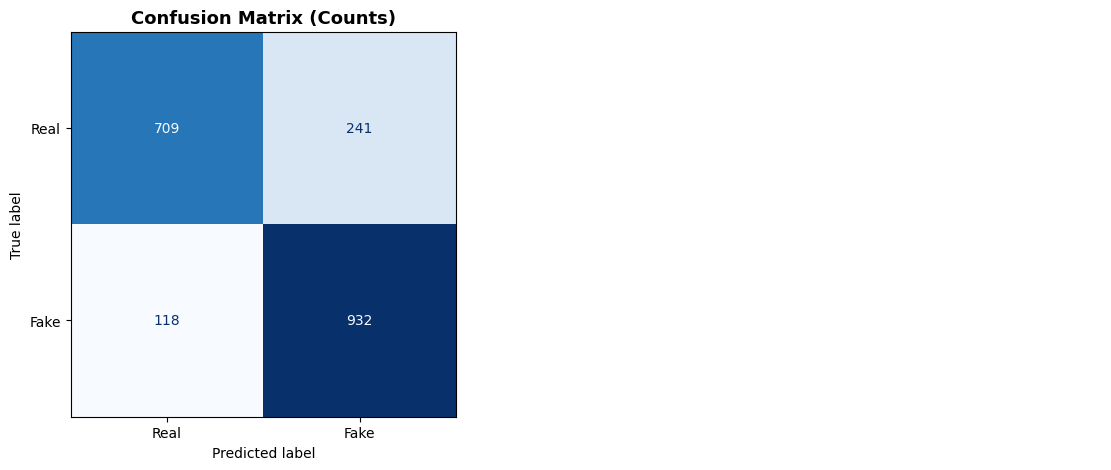

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Real", "Fake"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix (Counts)", fontsize=13, fontweight="bold")
axes[1].axis("off")

plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

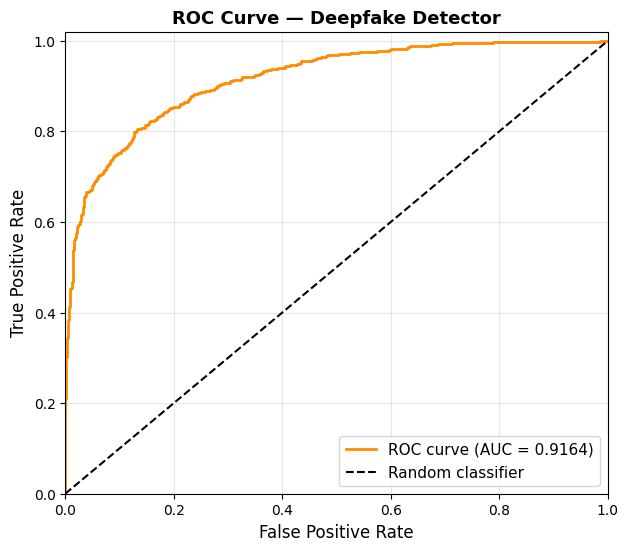

In [36]:
# ── 8.5 ROC Curve
fpr, tpr, thresholds = roc_curve(y_true, y_probs)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], "k--", lw=1.5, label="Random classifier")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.02])
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curve — Deepfake Detector", fontsize=13, fontweight="bold")
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.savefig("roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

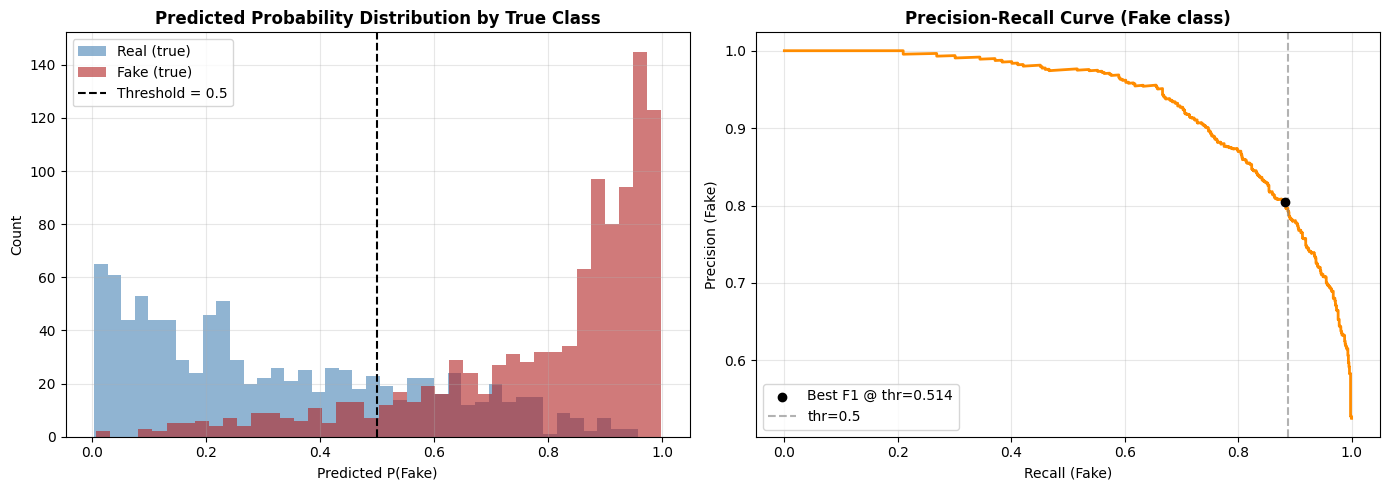

Default threshold (0.5)   -> Precision: 0.795 | Recall: 0.888
F1-optimal threshold      -> 0.514  (Precision: 0.805 | Recall: 0.882 | F1: 0.841)

--- Classification Report @ F1-optimal threshold ---
              precision    recall  f1-score   support

        Real       0.85      0.76      0.81       950
        Fake       0.80      0.88      0.84      1050

    accuracy                           0.83      2000
   macro avg       0.83      0.82      0.82      2000
weighted avg       0.83      0.83      0.82      2000


--- Per-Subclass Performance (at threshold=0.5) ---
Subclass              N   Recall   Mean P(Fake)
------------------------------------------------
real                950    0.746          0.320
deepfakes           210    0.962          0.858
face2face           210    0.924          0.825
faceshifter         210    0.871          0.778
faceswap            210    0.886          0.813
neuraltextures      210    0.795          0.693


In [37]:
# ── 8.6 Diagnostics: Probability Calibration & Per-Subclass Recall
# Uses y_probs, y_true, test_data already computed in cells 27-28.

from sklearn.metrics import precision_recall_curve, f1_score

# ---------------------------------------------------------------
# 1. Probability histogram split by true class
# ---------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(y_probs[y_true == 0], bins=40, alpha=0.6, color="steelblue", label="Real (true)")
axes[0].hist(y_probs[y_true == 1], bins=40, alpha=0.6, color="firebrick", label="Fake (true)")
axes[0].axvline(0.5, color="black", linestyle="--", linewidth=1.5, label="Threshold = 0.5")
axes[0].set_xlabel("Predicted P(Fake)")
axes[0].set_ylabel("Count")
axes[0].set_title("Predicted Probability Distribution by True Class", fontsize=12, fontweight="bold")
axes[0].legend()
axes[0].grid(alpha=0.3)

# ---------------------------------------------------------------
# 2. Precision-Recall curve + F1-optimal threshold search
# ---------------------------------------------------------------
precisions, recalls, pr_thresholds = precision_recall_curve(y_true, y_probs)

# F1 at each threshold (skip last point, which has no corresponding threshold)
f1_scores = 2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1] + 1e-9)
best_idx = int(np.argmax(f1_scores))
best_threshold = pr_thresholds[best_idx]
best_f1 = f1_scores[best_idx]

axes[1].plot(recalls, precisions, color="darkorange", lw=2)
axes[1].scatter(
    recalls[best_idx], precisions[best_idx],
    color="black", zorder=5,
    label=f"Best F1 @ thr={best_threshold:.3f}"
)
axes[1].axvline(recalls[np.argmin(np.abs(pr_thresholds - 0.5))], color="gray", linestyle="--", alpha=0.6, label="thr=0.5")
axes[1].set_xlabel("Recall (Fake)")
axes[1].set_ylabel("Precision (Fake)")
axes[1].set_title("Precision-Recall Curve (Fake class)", fontsize=12, fontweight="bold")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("calibration_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Default threshold (0.5)   -> Precision: {precisions[np.argmin(np.abs(pr_thresholds-0.5))]:.3f} | "
      f"Recall: {recalls[np.argmin(np.abs(pr_thresholds-0.5))]:.3f}")
print(f"F1-optimal threshold      -> {best_threshold:.3f}  (Precision: {precisions[best_idx]:.3f} | "
      f"Recall: {recalls[best_idx]:.3f} | F1: {best_f1:.3f})")

# Recompute predictions and report at the optimal threshold
y_pred_opt = (y_probs >= best_threshold).astype(int)
print("\n--- Classification Report @ F1-optimal threshold ---")
print(classification_report(y_true, y_pred_opt, target_names=["Real", "Fake"]))

# ---------------------------------------------------------------
# 3. Per-subclass recall breakdown (which fake methods are hardest?)
# ---------------------------------------------------------------
subclass_names = np.array([c for _, _, c in test_data])

print("\n--- Per-Subclass Performance (at threshold=0.5) ---")
print(f"{'Subclass':<16} {'N':>6} {'Recall':>8} {'Mean P(Fake)':>14}")
print("-" * 48)

# Real class for reference
real_mask = subclass_names == "real"
real_recall = np.mean(y_pred[real_mask] == 0)  # "recall" for Real = correctly predicted as Real
print(f"{'real':<16} {real_mask.sum():>6} {real_recall:>8.3f} {y_probs[real_mask].mean():>14.3f}")

for cls in sorted(set(subclass_names) - {"real"}):
    mask = subclass_names == cls
    cls_recall = np.mean(y_pred[mask] == 1)  # fraction correctly flagged as Fake
    mean_prob = y_probs[mask].mean()
    print(f"{cls:<16} {mask.sum():>6} {cls_recall:>8.3f} {mean_prob:>14.3f}")

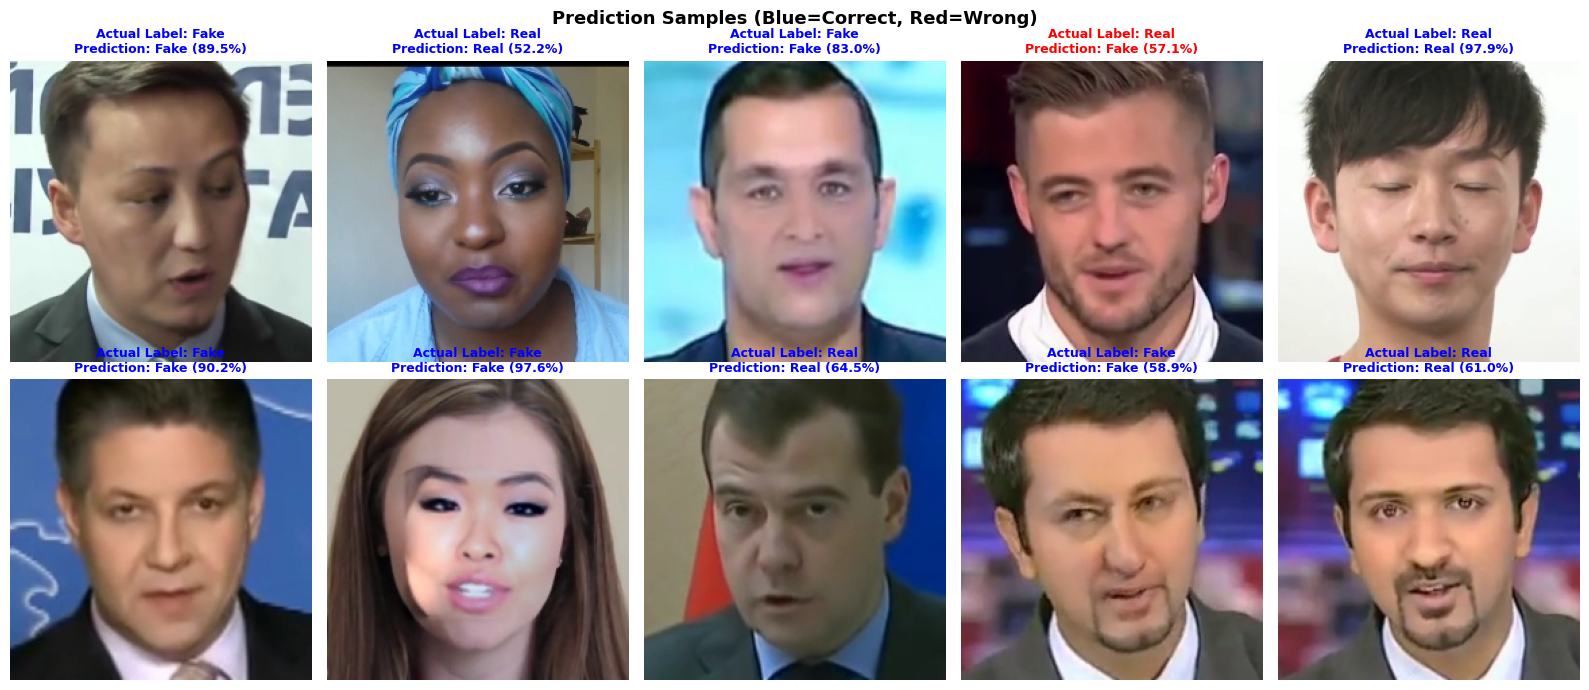

All evaluation plots saved.


In [40]:
# ── 8.8 Visual Prediction Samples
n_show = 10
indices = random.sample(range(len(test_data)), n_show)

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
axes = axes.flatten()

for i, idx in enumerate(indices):
    path, true_label, _ = test_data[idx]
    prob_fake = float(y_probs[idx])
    pred_label = 1 if prob_fake >= 0.5 else 0

    img = Image.open(path).resize(IMG_SIZE)
    axes[i].imshow(img)

    true_str  = "Real" if true_label == 0 else "Fake"
    pred_str  = "Real" if pred_label == 0 else "Fake"
    conf      = prob_fake if pred_label == 1 else 1 - prob_fake
    correct   = pred_label == true_label

    color = "blue" if correct else "red"
    title = f"Actual Label: {true_str}\nPrediction: {pred_str} ({conf*100:.1f}%)"
    axes[i].set_title(title, color=color, fontsize=9, fontweight="bold")
    axes[i].axis("off")
    if not correct:
        for spine in axes[i].spines.values():
            spine.set_edgecolor("red")
            spine.set_linewidth(3)

plt.suptitle("Prediction Samples (Blue=Correct, Red=Wrong)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("prediction_samples.png", dpi=150, bbox_inches="tight")
plt.show()
print("All evaluation plots saved.")